# Checking if we fit the NHANES data
See the original [CariesModelPaper](./CariesModelPaper.pdf).

In [2]:
# Setting up for experiments (don't change this cell -- default parameters shouldn't change)
from src.caries_20220319 import CariesV2
from src.tools.Experiment import Experiment
from src.tools.sample import Range, Values, Sample

parameters = {
        # Number of kids
        'agents': 2500,
        # Number of steps in the simulation
        'steps': 36,
        # Model will record every n-th step
        'record_steps': 1,
        # Random seed - can be set to None
        'seed': 17,
        # Main decay/filled/missing/sound parameters
        'person_decay_prob': 0.01356,
        'person_filling_prob': 0.00996,
        'sound_to_cavitated': 0.008994,
        'cavitated_to_missing': 0.00848,
        'person_decay_feedback': 0.25,
        # Fluoride parameters
        'fluoride_effect': 1.00,
        'fluoride_slope': 3.00,
        'fluoride_months_effective': 6.00,
        'person_preventive_fluoride': 1.00,
        'fluoride_scenario': 3.00,
        # High-risk Kid initialization parameters
        'init_caries_prevalence': 0.215311,
        'init_caries_prob': 0.16,
        'init_missing_prob': 0.00848,
        # Behavioral decay parameters
        'behavioral_decay': -1,
        'behavioral_feedback': 1,
        'disable_decay': 0
    }

## Setting (hyper)parameters

In [3]:
# Experiment name
experiment_name = 'OrigFeedback_Fluoride0p1effect0p1preventive_CariesV2_NHANES_fit_2500agents_30it'

# Iterations per sample
num_iterations = 30 
num_jobs = 1 #changes number of parallel runs (cpu usage)

exp_parameters = parameters.copy()

# Changing the number of agents (faster run-time)
num_agents = 2500
exp_parameters['agents'] = num_agents

# Setting behavioral parameters to the old default
exp_parameters['behavioral_decay'] = -1

# Setting fluoride to the baseline behavior
exp_parameters['person_preventive_fluoride'] = 0.0
exp_parameters['fluoride_scenario'] = 2.00
exp_parameters['person_preventive_fluoride'] = 0.1 # Talk about this value
exp_parameters['fluoride_effect'] = 0.1 # and this value

## Running the experiment

In [4]:
# Don't run this cell unless doing an experiment (experiments can take a while)
exp = Experiment(CariesV2, sample=exp_parameters, iterations=num_iterations, record=True)
results = exp.run(n_jobs=num_jobs)
results.save(exp_name=experiment_name)

Scheduled runs: 30
Completed: 30, estimated time remaining: 0:00:00
Experiment finished
Run time: 0:02:17.697127
Data is saved to model_output/OrigFeedback_Fluoride0p1effect0p1preventive_CariesV2_NHANES_fit_2500agents_30it_1


# Data Output Processing
Calculating the variables and metrics that we want to analyze.

Different samples ranges and experiment data need differing treatment.

In [5]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from src.tools.DataDict import DataDict

In [6]:
# Import data -- make sure exp_name is correct (takes from model_output folder and latest exp_id 
data_filled_missing = DataDict().load(exp_name=experiment_name) # set exp_id=:int: for specific choice

# extracting the desired dataframe (see README section to understand multi-index)
df = data_filled_missing.variables.Kid 

Loading from directory model_output/OrigFeedback_Fluoride0p1effect0p1preventive_CariesV2_NHANES_fit_2500agents_30it_1/
Loading info.json - Successful
Loading parameters_constants.json - Successful
Loading reporters.csv - Successful
Loading variables_Kid.csv - Successful


In [7]:
teeth_per_agent = 20
total_teeth = teeth_per_agent * num_iterations * num_agents
total_agents = num_iterations * num_agents

In [8]:

# Step 1: Boolean mask: caries present or not
caries_binary = df['caries_xp']

# Step 2: Mean caries presence per (iteration, t)
caries_mean_per_iter_t = caries_binary.groupby(['iteration', 't']).mean()

# Step 3: Std of those means across iterations, grouped by t
caries_std_per_t = caries_mean_per_iter_t.groupby('t').std()

# Optional: Also get the mean across iterations for each t
caries_mean_per_t = caries_mean_per_iter_t.groupby('t').mean()


In [10]:
# Step 1: Boolean mask: caries present or not
missing_count = df['missing']

# Step 2: Mean caries presence per (iteration, t)
# Mean number of missing teeth per agent - divide by 20 to get percentage per agent
missing_mean_per_iter_t = missing_count.groupby(['iteration', 't']).mean() / 20

# Step 3: Std of those means across iterations, grouped by t
missing_std_per_t = missing_mean_per_iter_t.groupby('t').std()

# Optional: Also get the mean across iterations for each t
missing_mean_per_t = missing_mean_per_iter_t.groupby('t').mean()

In [12]:
# Step 1
sound_count = df['sound']

# Step 2: Mean caries presence per (iteration, t)
# Mean number of missing teeth per agent - divide by 20 to get percentage per agent
sound_mean_per_iter_t = sound_count.groupby(['iteration', 't']).mean() / 20

# Step 3: Std of those means across iterations, grouped by t
sound_std_per_t = sound_mean_per_iter_t.groupby('t').std()

# Optional: Also get the mean across iterations for each t
sound_mean_per_t = sound_mean_per_iter_t.groupby('t').mean()

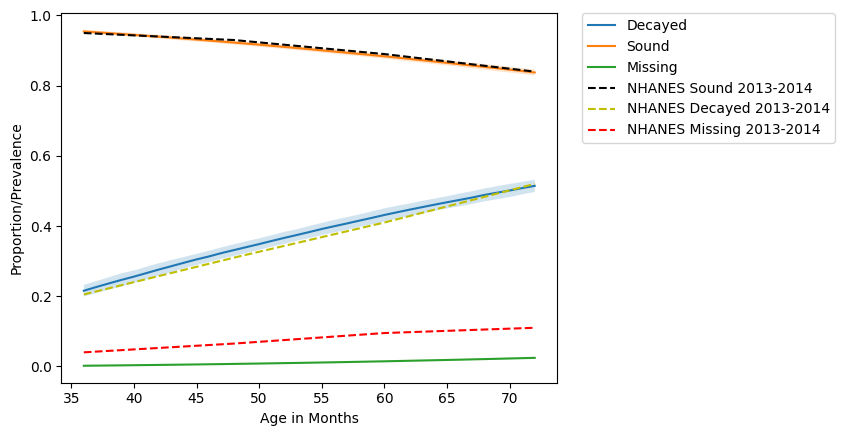

In [13]:

x = np.arange(37)
age_months = x + 36  # To match plot's axis

n = 1
z = 1.96  # for 95% CI

# Compute margins of error
caries_margin = z * caries_std_per_t / np.sqrt(n)
sound_margin = z * sound_std_per_t / np.sqrt(n)
missing_margin = z * missing_std_per_t / np.sqrt(n)

# Plot means and 95% confidence intervals
plt.plot(age_months, caries_mean_per_t, label="Decayed")
plt.fill_between(age_months, caries_mean_per_t - caries_margin, caries_mean_per_t + caries_margin, alpha=0.2)

plt.plot(age_months, sound_mean_per_t, label="Sound")
plt.fill_between(age_months, sound_mean_per_t - sound_margin, sound_mean_per_t + sound_margin, alpha=0.2)

plt.plot(age_months, missing_mean_per_t, label="Missing")
plt.fill_between(age_months, missing_mean_per_t - missing_margin, missing_mean_per_t + missing_margin, alpha=0.2)


# NHANES reference data points -- approximate
nhanes_ages = np.array([0, 12, 24, 36])  # Corresponds to 36, 48, 60, 72 months
sound_ref = np.array([0.95, 0.93, 0.89, 0.84])
decayed_ref = np.array([0.205, 0.31, 0.41, 0.52])
missing_ref = np.array([0.04, 0.065, 0.095, 0.11])

# Interpolate NHANES lines to x values
sound_nhanes = np.interp(x, nhanes_ages, sound_ref)
decayed_nhanes = np.interp(x, nhanes_ages, decayed_ref)
missing_nhanes = np.interp(x, nhanes_ages, missing_ref)


plt.plot(age_months, sound_nhanes, 'k--', label='NHANES Sound 2013-2014')
plt.plot(age_months, decayed_nhanes, 'y--', label='NHANES Decayed 2013-2014')
plt.plot(age_months, missing_nhanes, 'r--', label='NHANES Missing 2013-2014')

# Update legend so lines aren't duplicated
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.xlabel("Age in Months")
plt.ylabel("Proportion/Prevalence")

#plt.show()
plt.savefig('OrigFeedback_Fluoride0p1effect0p1preventive_NHANES_fit_fig.png', bbox_inches='tight')

In [15]:
df = pd.concat([
    caries_mean_per_t.rename('decayed_mean'),
    caries_std_per_t.rename('decayed_std'),
    sound_mean_per_t.rename('sound_mean'),
    sound_std_per_t.rename('sound_std'),
    missing_mean_per_t.rename('missing_mean'),
    missing_std_per_t.rename('missing_std')
], axis=1)
df.to_csv('OrigFeedback_Fluoride0p1effect0p1preventive_NHANES_fit_figure_data.csv')